
# Обучение модели YOLOv8 для Raspberry Pi

## Установка зависимостей

In [1]:
# Выполни один раз (если ещё не установлено):
# pip install ultralytics==8.4.9
# pip install opencv-python==4.11.0.86
# pip install numpy==1.26.4
# pip install portalocker==3.2.0

import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())

Python: 3.12.10
Platform: macOS-15.7.1-arm64-arm-64bit


## Импорт библиотек

In [2]:
from ultralytics import YOLO
import cv2
import yaml
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
import ultralytics
import torch

print("numpy", np.__version__)
print("ultralytics", ultralytics.__version__)
print("torch", torch.__version__)
print("platform", platform.platform())

numpy 1.26.4
ultralytics 8.4.9
torch 2.10.0
platform macOS-15.7.1-arm64-arm-64bit


## Экспорт датасета из Roboflow

- Создайте папку `dataset/`
- Распакуйте Roboflow zip **внутрь** `dataset/`

## Путь к датасету

In [4]:
# Укажите путь к папке, где лежит data.yaml
DATA_ROOT = Path("./dataset").resolve()

data_yaml_path = DATA_ROOT / "data.yaml"
print("DATA_ROOT =", DATA_ROOT)
print("data.yaml =", data_yaml_path)

assert DATA_ROOT.exists(), f"DATA_ROOT не найден: {DATA_ROOT}"
assert data_yaml_path.exists(), f"Не найден data.yaml: {data_yaml_path}"

DATA_ROOT = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset
data.yaml = /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/data.yaml


## Чтение data.yaml и формирование путей к train/valid/test

In [5]:
data = yaml.safe_load(data_yaml_path.read_text(encoding="utf-8"))

# valid → val
if "val" not in data and "valid" in data:
    data["val"] = data["valid"]

# classes
names = data["names"]
CLASS_NAMES = [names[i] for i in sorted(names)] if isinstance(names, dict) else names

yaml_dir = data_yaml_path.parent.resolve()   # .../dataset

def resolve_images_dir(v: str) -> Path:
    """ Изменить путь к папке с изображениями из data.yaml на абсолютный """
    p = Path(v)
    if p.is_absolute():
        # если абсолютный путь, вернуть как есть
        return p
    # если относительный, сначала попробовать относительно data.yaml
    p1 = (yaml_dir / p).resolve()
    if p1.exists():
        return p1
    # иначе убрать ведущие ../
    while p.parts and p.parts[0] == "..":
        p = Path(*p.parts[1:])
    return (yaml_dir / p).resolve()

train_images_dir = resolve_images_dir(data["train"])
val_images_dir   = resolve_images_dir(data["val"])
test_images_dir  = resolve_images_dir(data["test"]) if "test" in data else None

train_labels_dir = train_images_dir.parent / "labels"
val_labels_dir   = val_images_dir.parent / "labels"
test_labels_dir  = test_images_dir.parent / "labels" if test_images_dir else None

for p in (train_images_dir, train_labels_dir, val_images_dir, val_labels_dir):
    assert p.exists(), f"Не найдена папка: {p}"

print("Train:", train_images_dir)
print("Val:  ", val_images_dir)
if test_images_dir:
    print("Test: ", test_images_dir)

Train: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/train/images
Val:   /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/valid/images
Test:  /Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/test/images


## Демонстрация изображений из обучающего набора

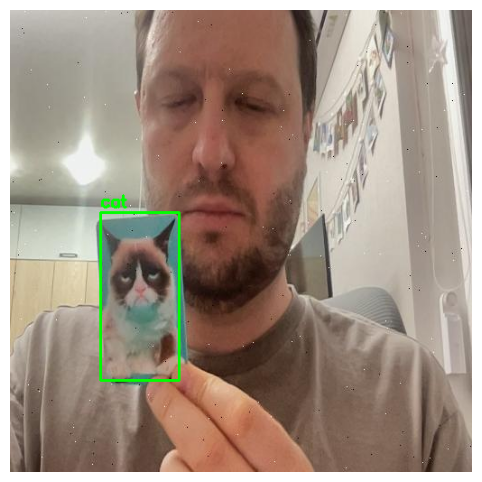

In [6]:
def read_yolo_labels(label_path: Path):
    boxes = []
    if not label_path.exists():
        return boxes
    txt = label_path.read_text(encoding="utf-8").strip()
    if not txt:
        return boxes
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls, xc, yc, w, h = parts
        boxes.append((int(cls), float(xc), float(yc), float(w), float(h)))
    return boxes

def draw_boxes(img_bgr, boxes, class_names):
    h, w = img_bgr.shape[:2]
    out = img_bgr.copy()
    for cls, xc, yc, bw, bh in boxes:
        x1 = int((xc - bw/2) * w)
        y1 = int((yc - bh/2) * h)
        x2 = int((xc + bw/2) * w)
        y2 = int((yc + bh/2) * h)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w-1, x2), min(h-1, y2)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0,255,0), 2)
        name = class_names[cls] if 0 <= cls < len(class_names) else str(cls)
        cv2.putText(out, name, (x1, max(0, y1-6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    return out

imgs = sorted(list(train_images_dir.glob("*.*")))
assert len(imgs) > 0, f"Нет изображений в {train_images_dir}"

for img_path in random.sample(imgs, k=min(1, len(imgs))):
    label_path = train_labels_dir / (img_path.stem + ".txt")
    img = cv2.imread(str(img_path))
    assert img is not None, f"Не удалось прочитать: {img_path}"
    boxes = read_yolo_labels(label_path)
    vis = draw_boxes(img, boxes, CLASS_NAMES)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(9, 6))
    plt.axis("off")
    plt.imshow(vis_rgb)
    plt.show()

## Обучение YOLOv8n

In [ ]:
MODEL_NAME = "yolov8n.pt"
EPOCHS = 50
IMGSZ_TRAIN = 320
BATCH = 16

DEVICE = "mps" # cpu, cuda, mps

WORKERS = 0

model = YOLO(MODEL_NAME)
train_results = model.train(
    data=str(data_yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ_TRAIN,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    project="runs_train",
    name="yolo8n",
    patience=20,
    close_mosaic=10,
)
print("Train done")

New https://pypi.org/project/ultralytics/8.4.10 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.9 🚀 Python-3.12.10 torch-2.10.0 MPS (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/aleksioprime/edu/gymnasium/sk_aisb/training/dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

## Валидация и лучшая модель

In [ ]:
best_pt = Path("runs/detect/runs_train/yolo8n/weights/best.pt")
last_pt = Path("runs/detect/runs_train/yolo8n/weights/last.pt")

print("best:", best_pt, "exists:", best_pt.exists())
print("last:", last_pt, "exists:", last_pt.exists())
assert best_pt.exists(), "Не найден best.pt — проверь, что обучение завершилось."

trained = YOLO(str(best_pt))

metrics = trained.val(
    data=str(data_yaml_path),
    imgsz=IMGSZ_TRAIN,
    device=DEVICE,
)
print(metrics)

## Предварительная оценка качества модели на валидационной выборке

In [ ]:
_ = trained.predict(
    source=str(val_images_dir),
    imgsz=320,
    conf=0.35,
    device=DEVICE,
    save=True,
    project="runs_predict",
    name="val_pred",
    verbose=False
)
print("Saved predictions to runs_predict/val_pred")

## Предварительная оценка качества модели на тестовой выборке

In [ ]:
if test_images_dir is not None:
    _ = trained.predict(
        source=str(test_images_dir),
        imgsz=320,
        conf=0.35,
        device=DEVICE,
        save=True,
        project="runs_predict",
        name="test_pred",
    )
    print("Saved predictions to runs_predict/test_pred")
else:
    print("Test dataset not found, skipping test predictions")

## Сохранение модели YOLO

In [ ]:
ART_DIR = Path("artifacts").resolve()
ART_DIR.mkdir(parents=True, exist_ok=True)

FINAL_DIR = ART_DIR / "yolo_export"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

best_model_path = Path(best_pt).resolve()
assert best_model_path.exists(), f"model.pt не найден: {best_model_path}"

final_best_pt = FINAL_DIR / "model.pt"
shutil.copy2(best_model_path, final_best_pt)

print("Saved:", final_best_pt)
print("FINAL_DIR:", FINAL_DIR)


## Экспорт YOLO в NCNN

In [ ]:
trained = YOLO(str(final_best_pt))

IMGSZ = 320

print(f"Export NCNN imgsz={IMGSZ} ...")
ncnn_path = trained.export(format="ncnn", imgsz=IMGSZ)

In [ ]:
trained = YOLO(str(final_best_pt))

IMGSZ = 320

print(f"Export TFLite imgsz={IMGSZ} ...")
tflite_path = trained.export(format="tflite", imgsz=IMGSZ)

# Очистка промежуточных файлов
p = FINAL_DIR / "model.onnx"
if p.exists():
    p.unlink()

for p in Path.cwd().glob("calibration_image_sample_data_*.npy"):
    p.unlink()

In [ ]:
zip_path = shutil.make_archive(str(FINAL_DIR), "zip", root_dir=str(FINAL_DIR))
print("Created ZIP:", zip_path)

Created ZIP: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts/yolo_export.zip


In [ ]:
TO_DELETE = [
    Path("runs"),          # Ultralytics default
    Path("runs_train"),    # если ты использовал такое
    Path("runs_predict"),  # если ты сохранял предикты туда
    Path("__pycache__"),
]

for p in TO_DELETE:
    p = p.resolve()
    if p.exists() and p.is_dir():
        # никогда не удаляем artifacts
        if p.name == "artifacts":
            continue
        shutil.rmtree(p)
        print("Deleted:", p)
    else:
        print("Skip:", p)

print("Cleanup done. Kept:", ART_DIR)

Deleted: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/runs
Skip: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/runs_train
Skip: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/runs_predict
Skip: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/__pycache__
Cleanup done. Kept: /Users/aleksioprime/edu/gymnasium/sk_aisb/training/artifacts
